<h1>Chapter 6-Linear and Logarithmic Transformations</h1>

<p>Suppose a company tracks how many days employees spend training on a software system and then measures their proficiency.<p/>
<p>•	At the beginning, employees learn quickly, and their scores increase sharply<br />
•	After more training, improvements continue, but at a slower rate</p>

<p>This pattern is known as diminishing marginal returns: each additional day of training contributes less to performance than the previous one.</p>

<p>We estimate two models:<br />
•	A standard linear model<br />
•	A transformed model using the natural logarithm of Days</p>


Dataset:
    Obs  Days  Score
0     1     6     67
1     2     7     77
2     3     9     83
3     4    11    130
4     5    12    112
5     6    19    189
6     7    22    162
7     8    33    233
8     9    40    233
9    10    41    265
10   11    51    235
11   12    53    276
12   13    56    301
13   14    65    301
14   15    76    295
15   16    85    367
16   17    91    315
17   18   104    315
18   19   106    296
19   20   111    322

Linear Regression Results:
                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     68.94
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.44e-07
Time:                        17:41:36   Log-Likelihood:                -102.84
No. Observations:                  20   AIC:    

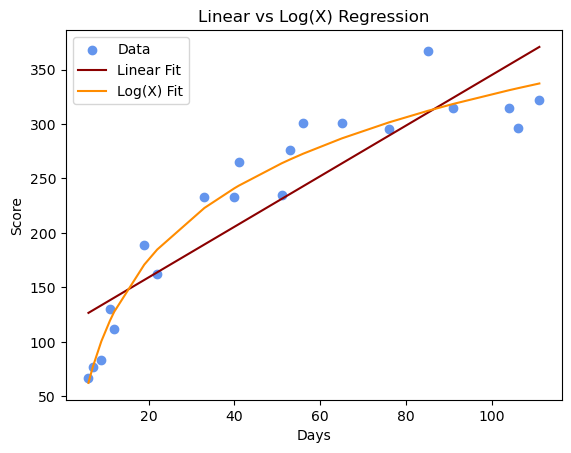

In [1]:
# ---------------------------------------------------------
# Linear Regression and Log(X) Regression Example
# Relationship: Days (x) and Score (y)
# ---------------------------------------------------------

# Import required libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Manually create the dataset
# ---------------------------------------------------------

data = {
    "Obs": list(range(1, 21)),
    
    # Independent variable (Days)
    "Days": [6,7,9,11,12,19,22,33,40,41,51,53,56,65,76,85,91,104,106,111],
    
    # Dependent variable (Score)
    "Score": [67,77,83,130,112,189,162,233,233,265,235,276,301,301,295,367,315,315,296,322]
}

# Convert into DataFrame
df = pd.DataFrame(data)

# Display dataset
print("Dataset:")
print(df)

# ---------------------------------------------------------
# STEP 2: Linear regression
# Model: y = β0 + β1*x + ε
# ---------------------------------------------------------

X_linear = sm.add_constant(df["Days"])
y = df["Score"]

model_linear = sm.OLS(y, X_linear).fit()

print("\nLinear Regression Results:")
print(model_linear.summary())

# ---------------------------------------------------------
# STEP 3: Log(X) regression
# Model: y = β0 + β1*ln(x) + ε
# This produces a concave (downward-bending) curve
# ---------------------------------------------------------

# Take natural log of Days
df["ln_Days"] = np.log(df["Days"])

X_logx = sm.add_constant(df["ln_Days"])

model_logx = sm.OLS(y, X_logx).fit()

print("\nLog(X) Regression Results:")
print(model_logx.summary())

# ---------------------------------------------------------
# STEP 4: Generate predictions for plotting
# ---------------------------------------------------------

# Sort data for smooth curves
df_sorted = df.sort_values(by="Days")

# Linear predictions
X_linear_sorted = sm.add_constant(df_sorted["Days"])
y_pred_linear = model_linear.predict(X_linear_sorted)

# Log(X) predictions
X_logx_sorted = sm.add_constant(np.log(df_sorted["Days"]))
y_pred_logx = model_logx.predict(X_logx_sorted)

# ---------------------------------------------------------
# STEP 5: Plot data and fitted models
# ---------------------------------------------------------

plt.figure()

# Scatter plot of actual data
plt.scatter(df["Days"], df["Score"], color="cornflowerblue")

# Linear regression line
plt.plot(df_sorted["Days"], y_pred_linear, color="darkred")

# Log(X) regression line (concave)
plt.plot(df_sorted["Days"], y_pred_logx, color="darkorange")

# Labels and title
plt.xlabel("Days")
plt.ylabel("Score")
plt.title("Linear vs Log(X) Regression")

# Legend
plt.legend(["Data","Linear Fit", "Log(X) Fit"])

# Display plot
plt.show()
